In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [2]:
BORUTA_TRIALS = 20

In [3]:
df = pd.read_csv('nr_ic_merged.csv')

In [4]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [5]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7fe60>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7ff40>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0040>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa00b0>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0120>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a730>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a7a0>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a810>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a880>


In [6]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [7]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7fe60>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7ff40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa00b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a730>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a7a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a810>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a880>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [9]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp,target_encoded
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7fe60>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370f7ff40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa00b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7fd370fa0120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a730>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a7a0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a810>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7fd371a2a880>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"


In [10]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [11]:
df_agg

,target,fp
0,"[0, 1, 1, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
7202,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7203,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7204,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7205,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [12]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [14]:
import numpy as np
import scipy.stats

if not hasattr(np, 'NaN'):
    np.NaN = np.nan
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

if not hasattr(scipy.stats, 'binom_test'):
    def binom_test_wrapper(x, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(x)
        n_clean = int(n) if n is not None else None

        return scipy.stats.binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue

    scipy.stats.binom_test = binom_test_wrapper

from BorutaShap import BorutaShap
import pandas as pd

feature_names = [f"Bit_{i}" for i in range(x.shape[1])]
X_df = pd.DataFrame(x, columns=feature_names)

target_names = encoder.categories_[0]

print(f"Feature Matrix Shape: {X_df.shape}")
print(f"Targets to analyze: {target_names}")

Feature Matrix Shape: (7207, 4096)
Targets to analyze: ['ar' 'era' 'erb' 'gr' 'mr' 'pr']


In [15]:
import numpy as np

for i, name in enumerate(target_names):
    n_pos = y[:, i].sum()
    n_neg = y.shape[0] - n_pos
    print(f"{name}: positives={n_pos}, negatives={n_neg}")

ar: positives=1802, negatives=5405
era: positives=2425, negatives=4782
erb: positives=1501, negatives=5706
gr: positives=1630, negatives=5577
mr: positives=781, negatives=6426
pr: positives=1368, negatives=5839



--- Processing Target: ar ---


  0%|          | 0/20 [00:00<?, ?it/s]

79 attributes confirmed important: ['bit_350', 'bit_1453', 'bit_2322', 'bit_1237', 'bit_1115', 'bit_1313', 'bit_3608', 'bit_2581', 'bit_1112', 'bit_2437', 'bit_1274', 'bit_2215', 'bit_3083', 'bit_2049', 'bit_162', 'bit_1959', 'bit_3184', 'bit_593', 'bit_622', 'bit_97', 'bit_13', 'bit_1928', 'bit_1862', 'bit_2857', 'bit_3839', 'bit_3826', 'bit_1256', 'bit_2838', 'bit_361', 'bit_25', 'bit_242', 'bit_695', 'bit_630', 'bit_81', 'bit_2883', 'bit_2429', 'bit_92', 'bit_1236', 'bit_3082', 'bit_2128', 'bit_3432', 'bit_1582', 'bit_3524', 'bit_3880', 'bit_2787', 'bit_3650', 'bit_3637', 'bit_3470', 'bit_899', 'bit_3798', 'bit_1686', 'bit_2793', 'bit_2091', 'bit_371', 'bit_529', 'bit_262', 'bit_980', 'bit_5', 'bit_3743', 'bit_1818', 'bit_2944', 'bit_2281', 'bit_2467', 'bit_3000', 'bit_3276', 'bit_3475', 'bit_3108', 'bit_194', 'bit_1160', 'bit_3530', 'bit_807', 'bit_3940', 'bit_2162', 'bit_2067', 'bit_439', 'bit_2380', 'bit_3851', 'bit_2722', 'bit_1536']
3538 attributes confirmed unimportant: ['bit_

<Figure size 1200x600 with 0 Axes>

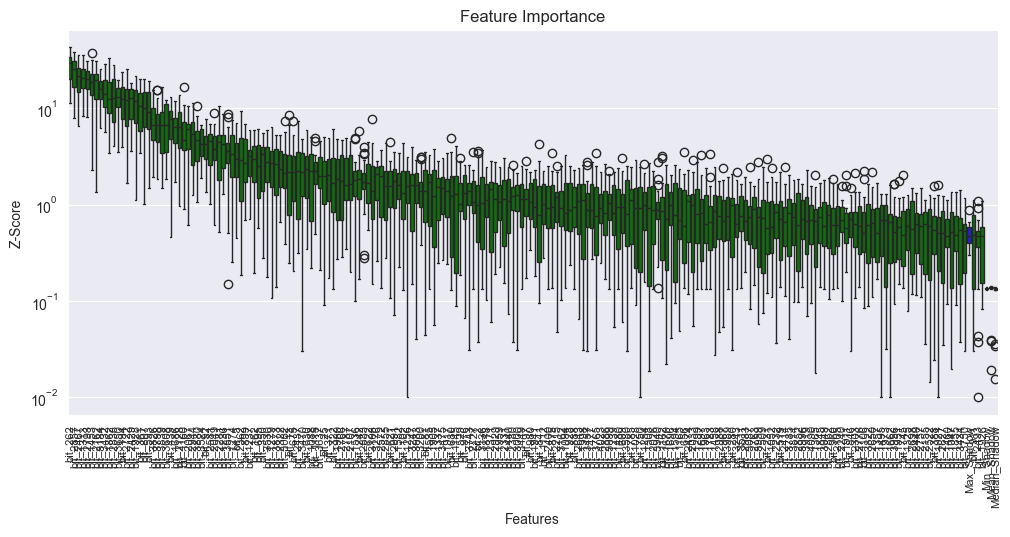

    -> Saved 'boruta_plot_ar.png'
    -> 208 features selected.

--- Processing Target: era ---


  0%|          | 0/20 [00:00<?, ?it/s]

132 attributes confirmed important: ['bit_2362', 'bit_1453', 'bit_734', 'bit_1237', 'bit_646', 'bit_1313', 'bit_3608', 'bit_2581', 'bit_3900', 'bit_2', 'bit_3578', 'bit_2437', 'bit_1274', 'bit_2215', 'bit_119', 'bit_2766', 'bit_1052', 'bit_3184', 'bit_2727', 'bit_280', 'bit_593', 'bit_4030', 'bit_2290', 'bit_2107', 'bit_1239', 'bit_2983', 'bit_13', 'bit_1928', 'bit_1862', 'bit_2857', 'bit_1088', 'bit_1120', 'bit_3162', 'bit_3018', 'bit_3839', 'bit_3959', 'bit_3826', 'bit_1256', 'bit_3956', 'bit_2926', 'bit_2838', 'bit_2682', 'bit_361', 'bit_25', 'bit_2974', 'bit_1670', 'bit_1475', 'bit_695', 'bit_630', 'bit_1594', 'bit_1154', 'bit_841', 'bit_2883', 'bit_2429', 'bit_3105', 'bit_3458', 'bit_3082', 'bit_2134', 'bit_1476', 'bit_2128', 'bit_1060', 'bit_3863', 'bit_3432', 'bit_3922', 'bit_928', 'bit_1582', 'bit_3880', 'bit_2787', 'bit_4036', 'bit_3650', 'bit_3200', 'bit_1487', 'bit_2932', 'bit_3470', 'bit_976', 'bit_3798', 'bit_122', 'bit_1686', 'bit_1440', 'bit_102', 'bit_2793', 'bit_31', '

<Figure size 1200x600 with 0 Axes>

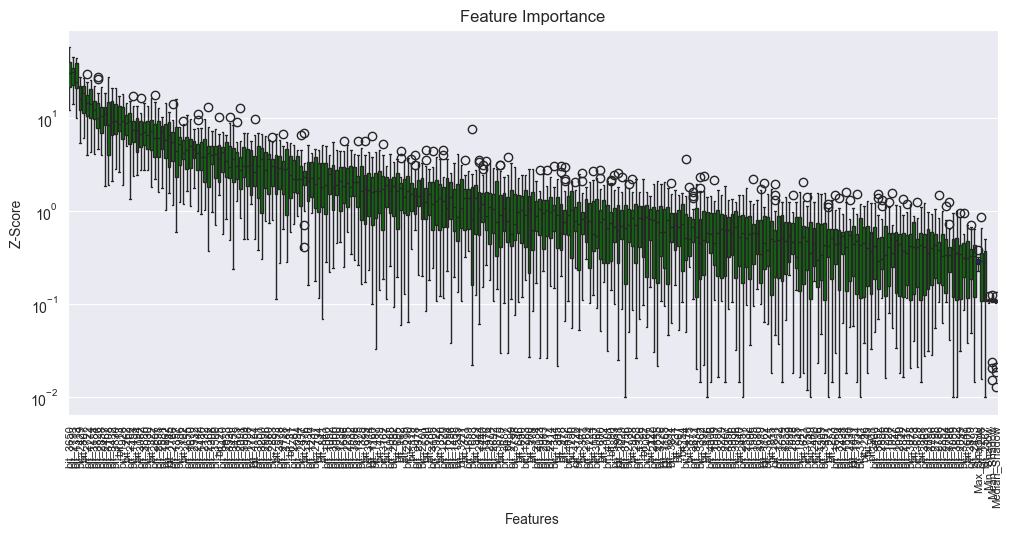

    -> Saved 'boruta_plot_era.png'
    -> 257 features selected.

--- Processing Target: erb ---


  0%|          | 0/20 [00:00<?, ?it/s]

83 attributes confirmed important: ['bit_350', 'bit_1453', 'bit_1313', 'bit_3900', 'bit_2581', 'bit_3608', 'bit_3578', 'bit_1274', 'bit_2215', 'bit_54', 'bit_162', 'bit_3184', 'bit_2727', 'bit_280', 'bit_593', 'bit_4030', 'bit_2107', 'bit_2983', 'bit_13', 'bit_1928', 'bit_1862', 'bit_2857', 'bit_1088', 'bit_3162', 'bit_3839', 'bit_3826', 'bit_3956', 'bit_4032', 'bit_2838', 'bit_690', 'bit_1670', 'bit_1475', 'bit_1594', 'bit_841', 'bit_2429', 'bit_3105', 'bit_3458', 'bit_699', 'bit_3087', 'bit_3432', 'bit_3880', 'bit_4036', 'bit_3650', 'bit_3200', 'bit_1487', 'bit_675', 'bit_2932', 'bit_90', 'bit_3470', 'bit_750', 'bit_3652', 'bit_1440', 'bit_2793', 'bit_1659', 'bit_2091', 'bit_3655', 'bit_2017', 'bit_1535', 'bit_1325', 'bit_1059', 'bit_2997', 'bit_262', 'bit_1047', 'bit_2440', 'bit_2300', 'bit_2467', 'bit_2007', 'bit_2799', 'bit_1480', 'bit_1998', 'bit_3108', 'bit_194', 'bit_3530', 'bit_807', 'bit_2698', 'bit_1436', 'bit_656', 'bit_2162', 'bit_439', 'bit_3851', 'bit_2722', 'bit_3136', 

<Figure size 1200x600 with 0 Axes>

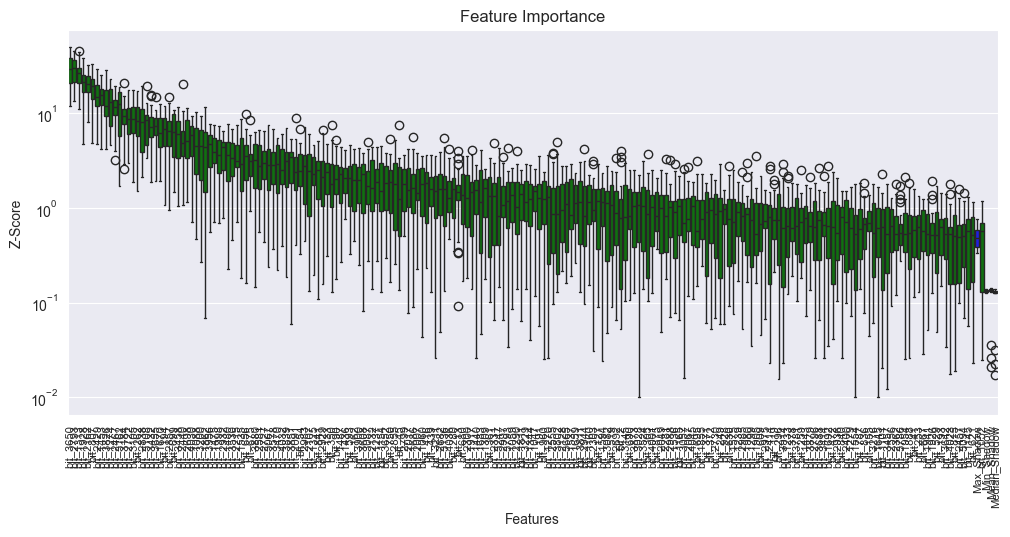

    -> Saved 'boruta_plot_erb.png'
    -> 202 features selected.

--- Processing Target: gr ---


  0%|          | 0/20 [00:00<?, ?it/s]

126 attributes confirmed important: ['bit_2362', 'bit_883', 'bit_350', 'bit_4045', 'bit_1237', 'bit_45', 'bit_1313', 'bit_3608', 'bit_3900', 'bit_1274', 'bit_3770', 'bit_3184', 'bit_3253', 'bit_2727', 'bit_280', 'bit_1941', 'bit_1147', 'bit_593', 'bit_2290', 'bit_2107', 'bit_2983', 'bit_13', 'bit_1928', 'bit_1687', 'bit_1862', 'bit_2857', 'bit_1088', 'bit_1970', 'bit_2550', 'bit_3744', 'bit_3162', 'bit_1252', 'bit_3839', 'bit_3826', 'bit_1219', 'bit_3956', 'bit_3986', 'bit_2838', 'bit_2682', 'bit_1162', 'bit_361', 'bit_1670', 'bit_630', 'bit_695', 'bit_1594', 'bit_1154', 'bit_841', 'bit_3903', 'bit_2429', 'bit_3105', 'bit_1885', 'bit_3458', 'bit_699', 'bit_3211', 'bit_3082', 'bit_2441', 'bit_3232', 'bit_1640', 'bit_3087', 'bit_635', 'bit_3432', 'bit_3786', 'bit_3524', 'bit_3880', 'bit_621', 'bit_3650', 'bit_3200', 'bit_671', 'bit_2932', 'bit_1418', 'bit_1421', 'bit_90', 'bit_892', 'bit_2905', 'bit_3919', 'bit_2456', 'bit_3652', 'bit_1440', 'bit_2284', 'bit_1021', 'bit_2793', 'bit_2091'

<Figure size 1200x600 with 0 Axes>

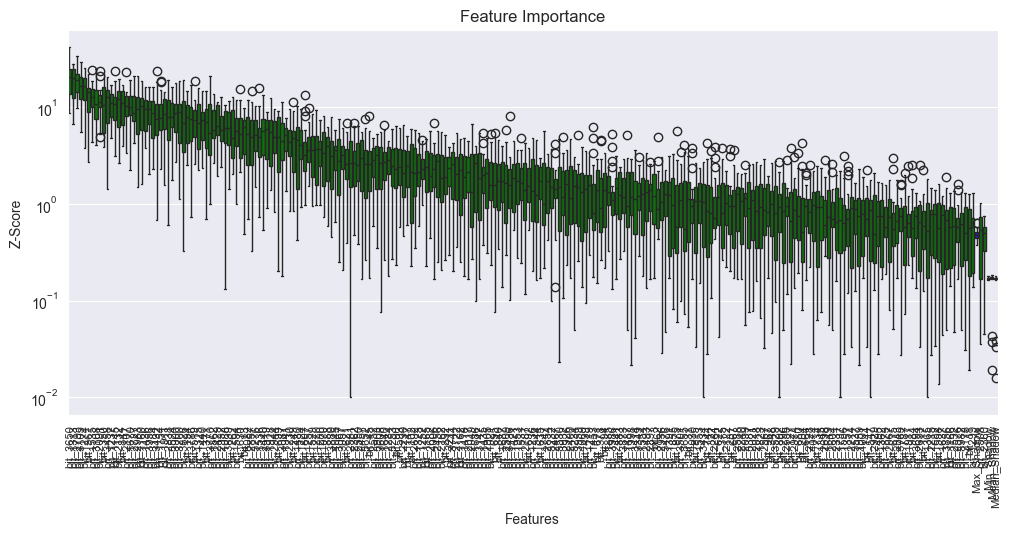

    -> Saved 'boruta_plot_gr.png'
    -> 241 features selected.

--- Processing Target: mr ---


  0%|          | 0/20 [00:00<?, ?it/s]

74 attributes confirmed important: ['bit_1646', 'bit_4001', 'bit_350', 'bit_2377', 'bit_3574', 'bit_3162', 'bit_2920', 'bit_132', 'bit_1487', 'bit_3200', 'bit_3650', 'bit_671', 'bit_3895', 'bit_2518', 'bit_609', 'bit_873', 'bit_1338', 'bit_94', 'bit_3826', 'bit_1313', 'bit_944', 'bit_692', 'bit_1435', 'bit_3276', 'bit_1274', 'bit_1755', 'bit_2793', 'bit_3083', 'bit_971', 'bit_1365', 'bit_690', 'bit_1670', 'bit_2766', 'bit_3108', 'bit_630', 'bit_1594', 'bit_608', 'bit_2698', 'bit_3219', 'bit_807', 'bit_841', 'bit_888', 'bit_3802', 'bit_2429', 'bit_993', 'bit_656', 'bit_929', 'bit_1101', 'bit_1911', 'bit_3822', 'bit_593', 'bit_4030', 'bit_3458', 'bit_699', 'bit_441', 'bit_3914', 'bit_3262', 'bit_3756', 'bit_3330', 'bit_262', 'bit_2107', 'bit_1575', 'bit_2303', 'bit_1145', 'bit_3782', 'bit_2929', 'bit_2983', 'bit_3699', 'bit_1060', 'bit_2440', 'bit_1905', 'bit_2127', 'bit_322', 'bit_2550']
3759 attributes confirmed unimportant: ['bit_2148', 'bit_1234', 'bit_1830', 'bit_1526', 'bit_2337', 

<Figure size 1200x600 with 0 Axes>

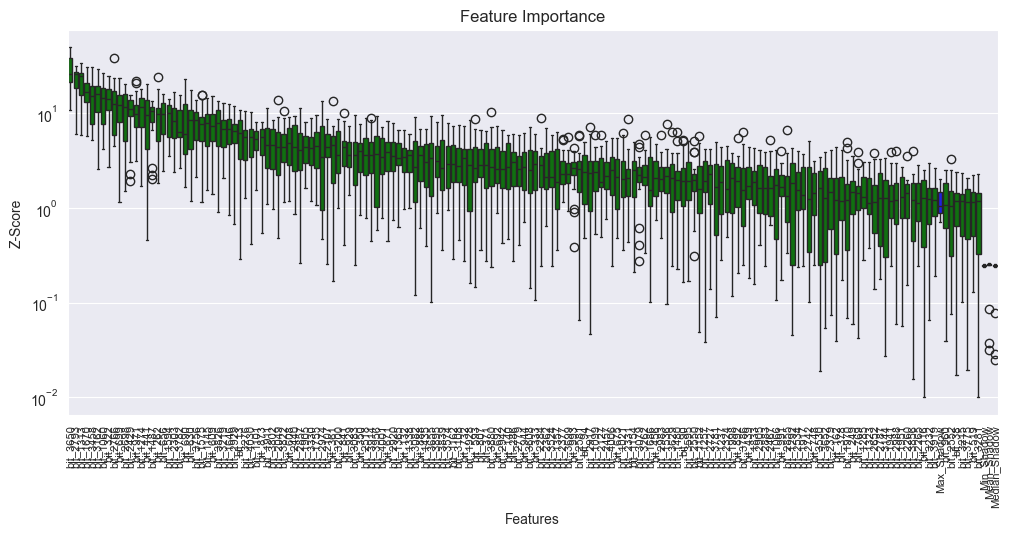

    -> Saved 'boruta_plot_mr.png'
    -> 166 features selected.

--- Processing Target: pr ---


  0%|          | 0/20 [00:00<?, ?it/s]

84 attributes confirmed important: ['bit_2362', 'bit_1313', 'bit_3900', 'bit_2581', 'bit_2438', 'bit_1638', 'bit_1274', 'bit_2503', 'bit_2766', 'bit_3184', 'bit_2727', 'bit_1973', 'bit_1917', 'bit_4030', 'bit_1692', 'bit_2290', 'bit_2983', 'bit_13', 'bit_1382', 'bit_2857', 'bit_3162', 'bit_3414', 'bit_3839', 'bit_3826', 'bit_2798', 'bit_2838', 'bit_2413', 'bit_2682', 'bit_3434', 'bit_1475', 'bit_695', 'bit_1594', 'bit_841', 'bit_2429', 'bit_3144', 'bit_3105', 'bit_815', 'bit_3028', 'bit_3211', 'bit_960', 'bit_3082', 'bit_1626', 'bit_2128', 'bit_1060', 'bit_3432', 'bit_928', 'bit_2738', 'bit_3880', 'bit_3650', 'bit_3200', 'bit_1683', 'bit_3470', 'bit_296', 'bit_2793', 'bit_3655', 'bit_2132', 'bit_127', 'bit_1535', 'bit_3873', 'bit_2017', 'bit_378', 'bit_2944', 'bit_2281', 'bit_2692', 'bit_3500', 'bit_1480', 'bit_2730', 'bit_1998', 'bit_3108', 'bit_1160', 'bit_3530', 'bit_3781', 'bit_807', 'bit_372', 'bit_2122', 'bit_216', 'bit_439', 'bit_785', 'bit_1980', 'bit_1357', 'bit_2855', 'bit_27

<Figure size 1200x600 with 0 Axes>

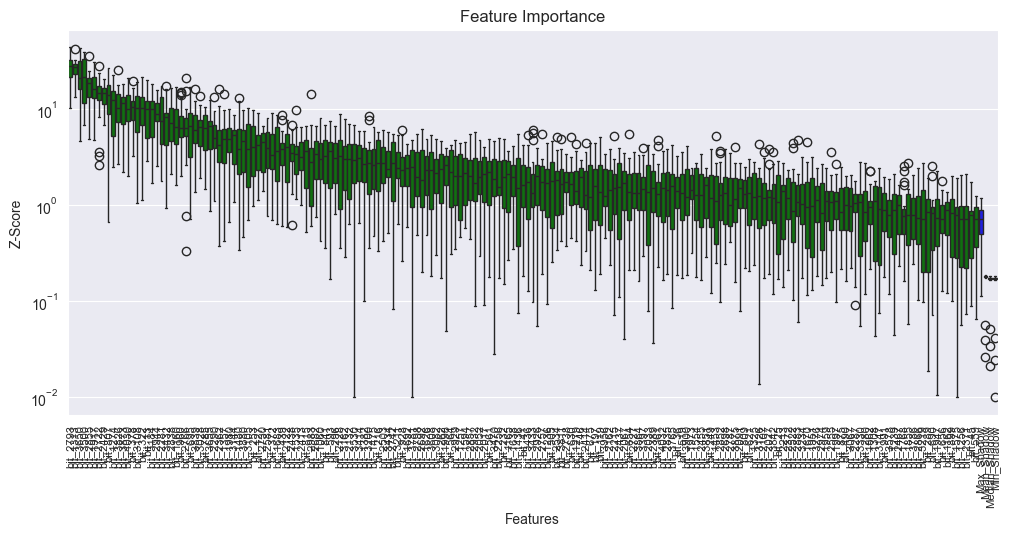

    -> Saved 'boruta_plot_pr.png'
    -> 189 features selected.

Success! Z-scores matrix saved to 'boruta_zscores_matrix.csv'


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BorutaShap import BorutaShap
from xgboost import XGBClassifier

# --- 1. SETUP ---
# Assumptions: 'x', 'y', 'target_names', and 'BORUTA_TRIALS' are already defined
feature_names = [f"bit_{i}" for i in range(x.shape[1])]
X_boruta = pd.DataFrame(x, columns=feature_names)

# Dictionary to store the final list of "kept" features for each target
selected_features_per_target = {}

# RF Configuration
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    class_weight='balanced',
    n_jobs=-1
)

zscore_results = []

# --- 2. LOOP PER TARGET ---
for i, target_name in enumerate(target_names):
    print(f"\n--- Processing Target: {target_name} ---")

    y_target = pd.Series(y[:, i], name=target_name)

    # Initialize BorutaShap
    selector = BorutaShap(
        model=rf_model,
        importance_measure='shap',
        classification=True
    )

    try:
        # Fit Boruta
        # verbose=True will usually print a text summary automatically
        selector.fit(X=X_boruta, y=y_target, n_trials=BORUTA_TRIALS, sample=False, verbose=True)

        mean_z_scores = selector.history_x.mean(axis=0)
        mean_z_scores.name = target_name  # Set the row name to the receptor/target

        # Append to our results list
        zscore_results.append(mean_z_scores)

        # Cleanup tentative features (optional, but good for finality)
        selector.TentativeRoughFix()

        # --- USE THE BUILT-IN FUNCTION ---
        # This generates the boxplot of Accepted Features vs Shadow Features
        print(f"Generating plot for {target_name}...")

        # We start a new figure to avoid overwriting/stacking
        plt.figure(figsize=(12, 6))

        # 'accepted' shows only the confirmed features.
        # You can use 'all' if you want to see everything (can be messy).
        selector.plot(which_features='accepted', figsize=(12, 5))

        # Save the plot automatically
        safe_name = target_name.replace('/', '_').replace(' ', '_')
        plt.title(f"Boruta Importance: {target_name}")
        plt.tight_layout()
        plt.savefig(f"boruta_plot_{safe_name}.png", dpi=300)
        plt.close() # Close to free memory

        # Store the selected features list for your downstream tasks
        subset = selector.Subset()
        selected_features_per_target[target_name] = subset.columns.tolist()

        print(f"    -> Saved 'boruta_plot_{safe_name}.png'")
        print(f"    -> {len(subset.columns)} features selected.")

    except Exception as e:
        print(f"    -> Failed for {target_name}: {e}")

# --- 3. EXPORT TO CSV ---
# Create DataFrame from the list of Series
# This aligns all bits automatically; if a bit was missing in one run (unlikely with same X), it handles it.
final_zscore_df = pd.DataFrame(zscore_results)

# Fill NaNs with 0 (if any)
final_zscore_df = final_zscore_df.fillna(0)

# Save to CSV
# Index (Rows) = Targets (Receptors)
# Columns = Bits (ECFP)
final_zscore_df.to_csv('boruta_zscores_matrix_rf.csv', index=True)

print("\nSuccess! Z-scores matrix saved to 'boruta_zscores_matrix.csv'")